# Scanpy clustering pipeline

Simple preprocessing → QC → normalization → PCA → UMAP → Leiden clustering at multiple resolutions.

Set `FILE_IDX` below to pick the dataset:
| idx | file | cells |
|-----|------|-------|
| 0 | SRX13198730 | 9,419 |
| 1 | SRX17412841 | 5,506 |
| 2 | SRX22996378 | 3,413 |

## 1. Setup

In [1]:
from __future__ import annotations
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np

sc.settings.set_figure_params(dpi=80, figsize=(5, 4), facecolor="white")

H5AD_DIR = Path("../data/scbasecount/2026-01-12/h5ad/GeneFull/Homo_sapiens")
h5ad_files = sorted(H5AD_DIR.glob("*.h5ad"))

FILE_IDX = 0

adata = sc.read(h5ad_files[FILE_IDX])
adata.obs_names_make_unique()
print(adata)

/var/folders/rj/58krw3q53619qt2rbck9wq740000gn/T/ipykernel_76945/207865556.py:7: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, figsize=(5, 4), facecolor="white")


AnnData object with n_obs × n_vars = 9419 × 36601
    obs: 'gene_count_Unique', 'umi_count_Unique', 'gene_count_UniqueAndMult-EM', 'umi_count_UniqueAndMult-EM', 'gene_count_UniqueAndMult-Uniform', 'umi_count_UniqueAndMult-Uniform', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'UniqueAndMult-EM', 'UniqueAndMult-Uniform'


## 2. QC

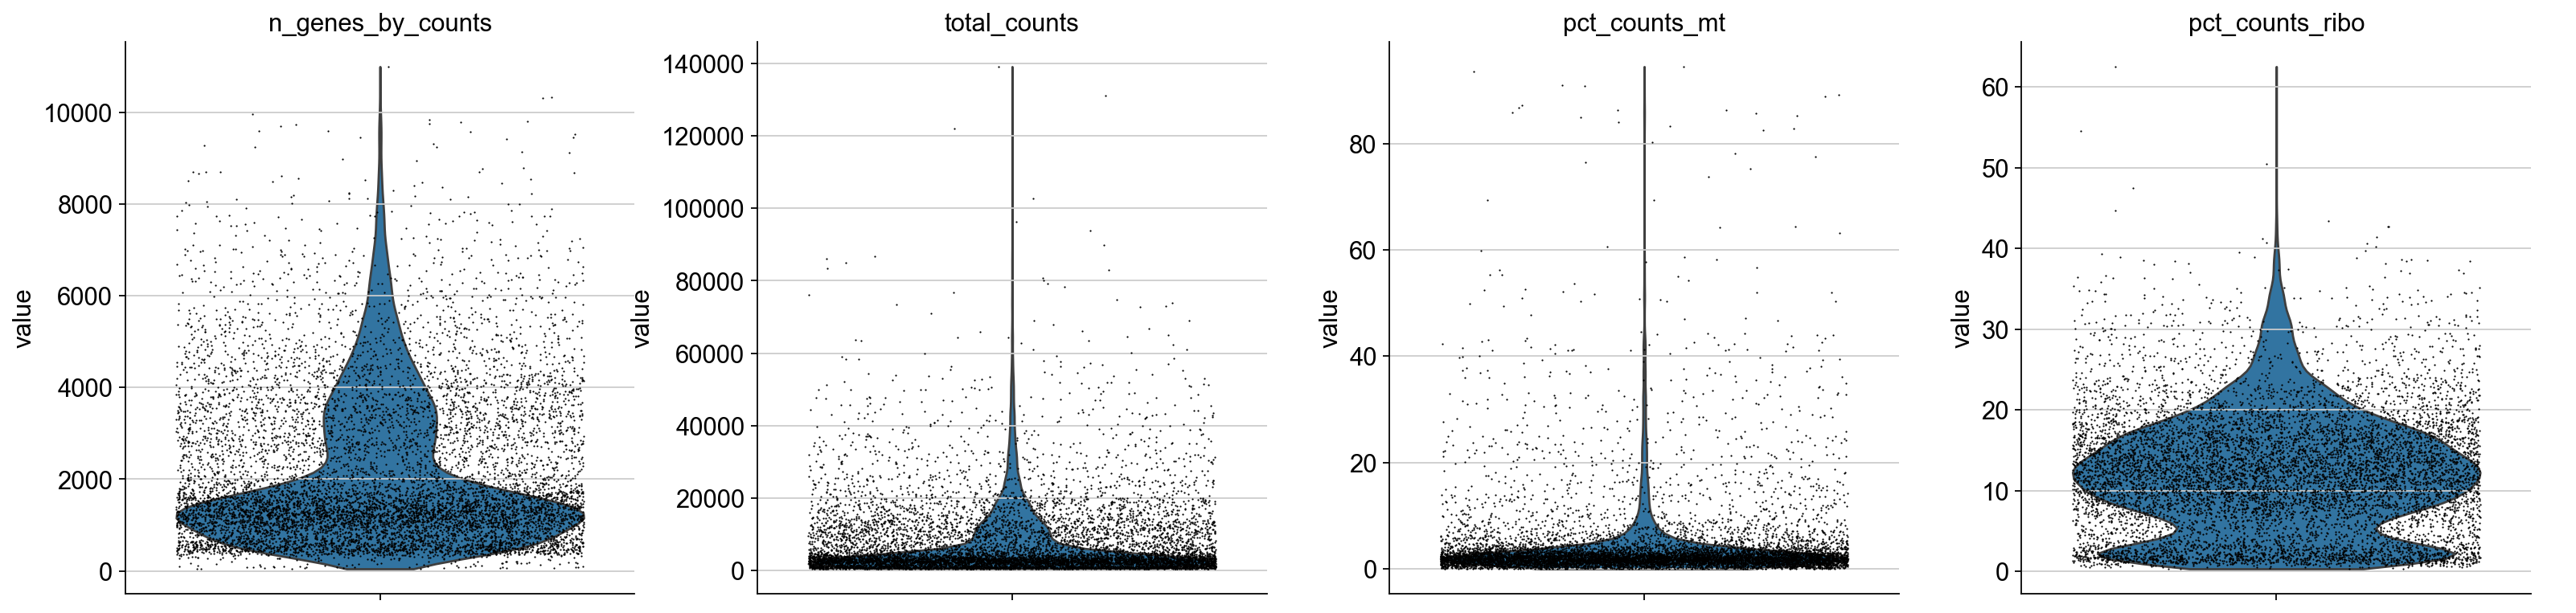

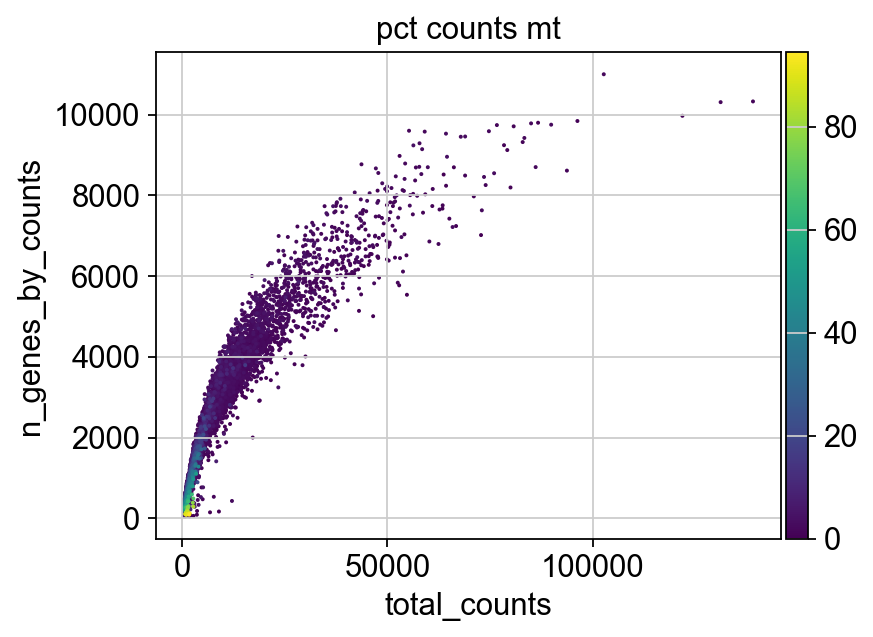

In [2]:
# var_names are ENSEMBL IDs; gene symbols are in adata.var["gene_symbols"]
adata.var["mt"] = adata.var["gene_symbols"].str.startswith("MT-")
adata.var["ribo"] = adata.var["gene_symbols"].str.match(r"^RP[SL]\d")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=False)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

In [3]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
print(adata)

AnnData object with n_obs × n_vars = 9003 × 26557
    obs: 'gene_count_Unique', 'umi_count_Unique', 'gene_count_UniqueAndMult-EM', 'umi_count_UniqueAndMult-EM', 'gene_count_UniqueAndMult-Uniform', 'umi_count_UniqueAndMult-Uniform', 'SRX_accession', 'cell_type', 'cell_ontology_term_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'gene_symbols', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'UniqueAndMult-EM', 'UniqueAndMult-Uniform'


## 3. Preprocessing

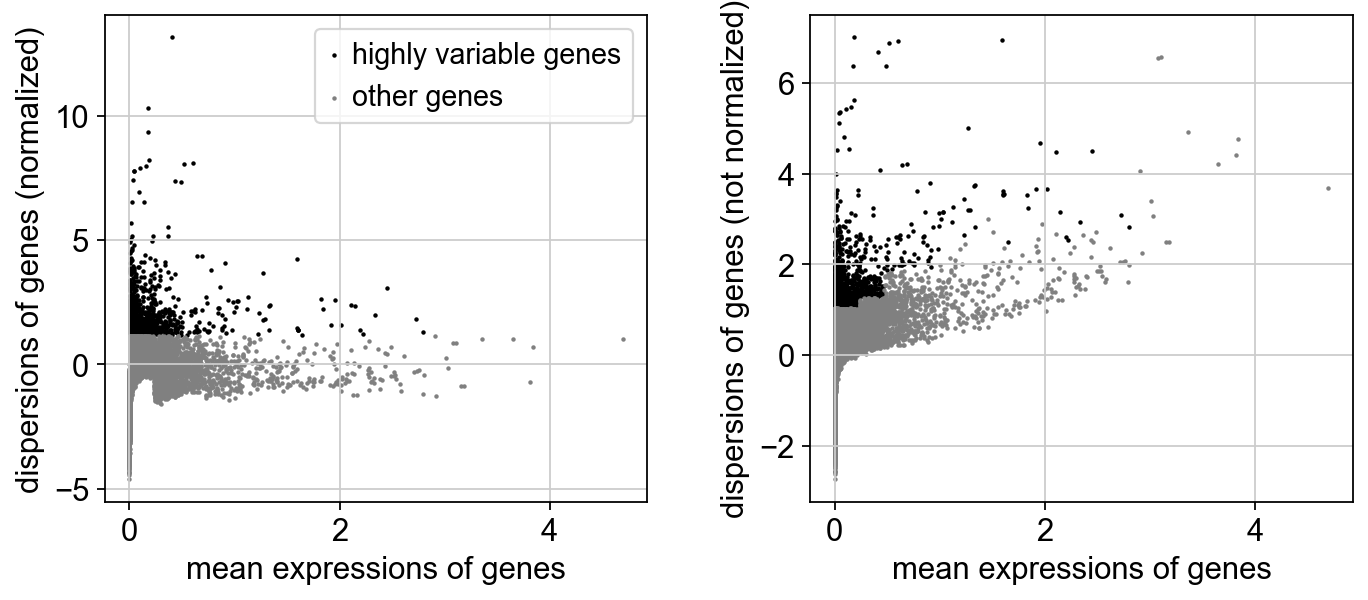

In [4]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

## 4. Dimensionality reduction

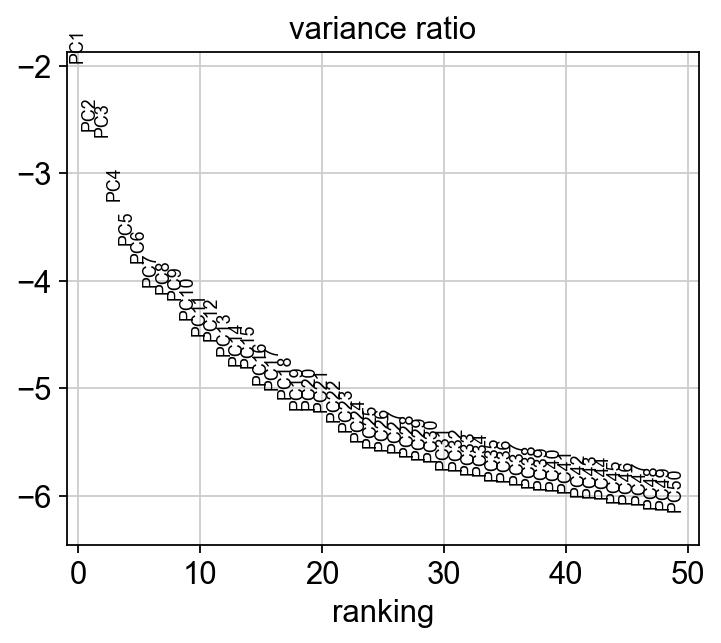

In [5]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [6]:
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)

/Users/otodreas/Desktop/Work/Nygen/scBaseCount_Pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5. Clustering resolutions

Run Leiden at four resolutions. Higher resolution → more (finer) clusters.
`cell_type` is the STATE-algorithm annotation and serves as a weak reference.

In [7]:
RESOLUTIONS = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

for r in RESOLUTIONS:
    sc.tl.leiden(adata, resolution=r, flavor="igraph", n_iterations=2, directed=False, key_added=f"leiden_{r}")

counts = {
    f"leiden_{r}": adata.obs[f"leiden_{r}"].nunique()
    for r in RESOLUTIONS
}
print("number of clusters:")
print(pd.Series(counts, name="n_clusters").to_string())
print(f"number of cell types: {len(np.unique(adata.obs["cell_type"]))}")

ImportError: Please install the igraph package: `conda install -c conda-forge python-igraph` or `pip install igraph`.

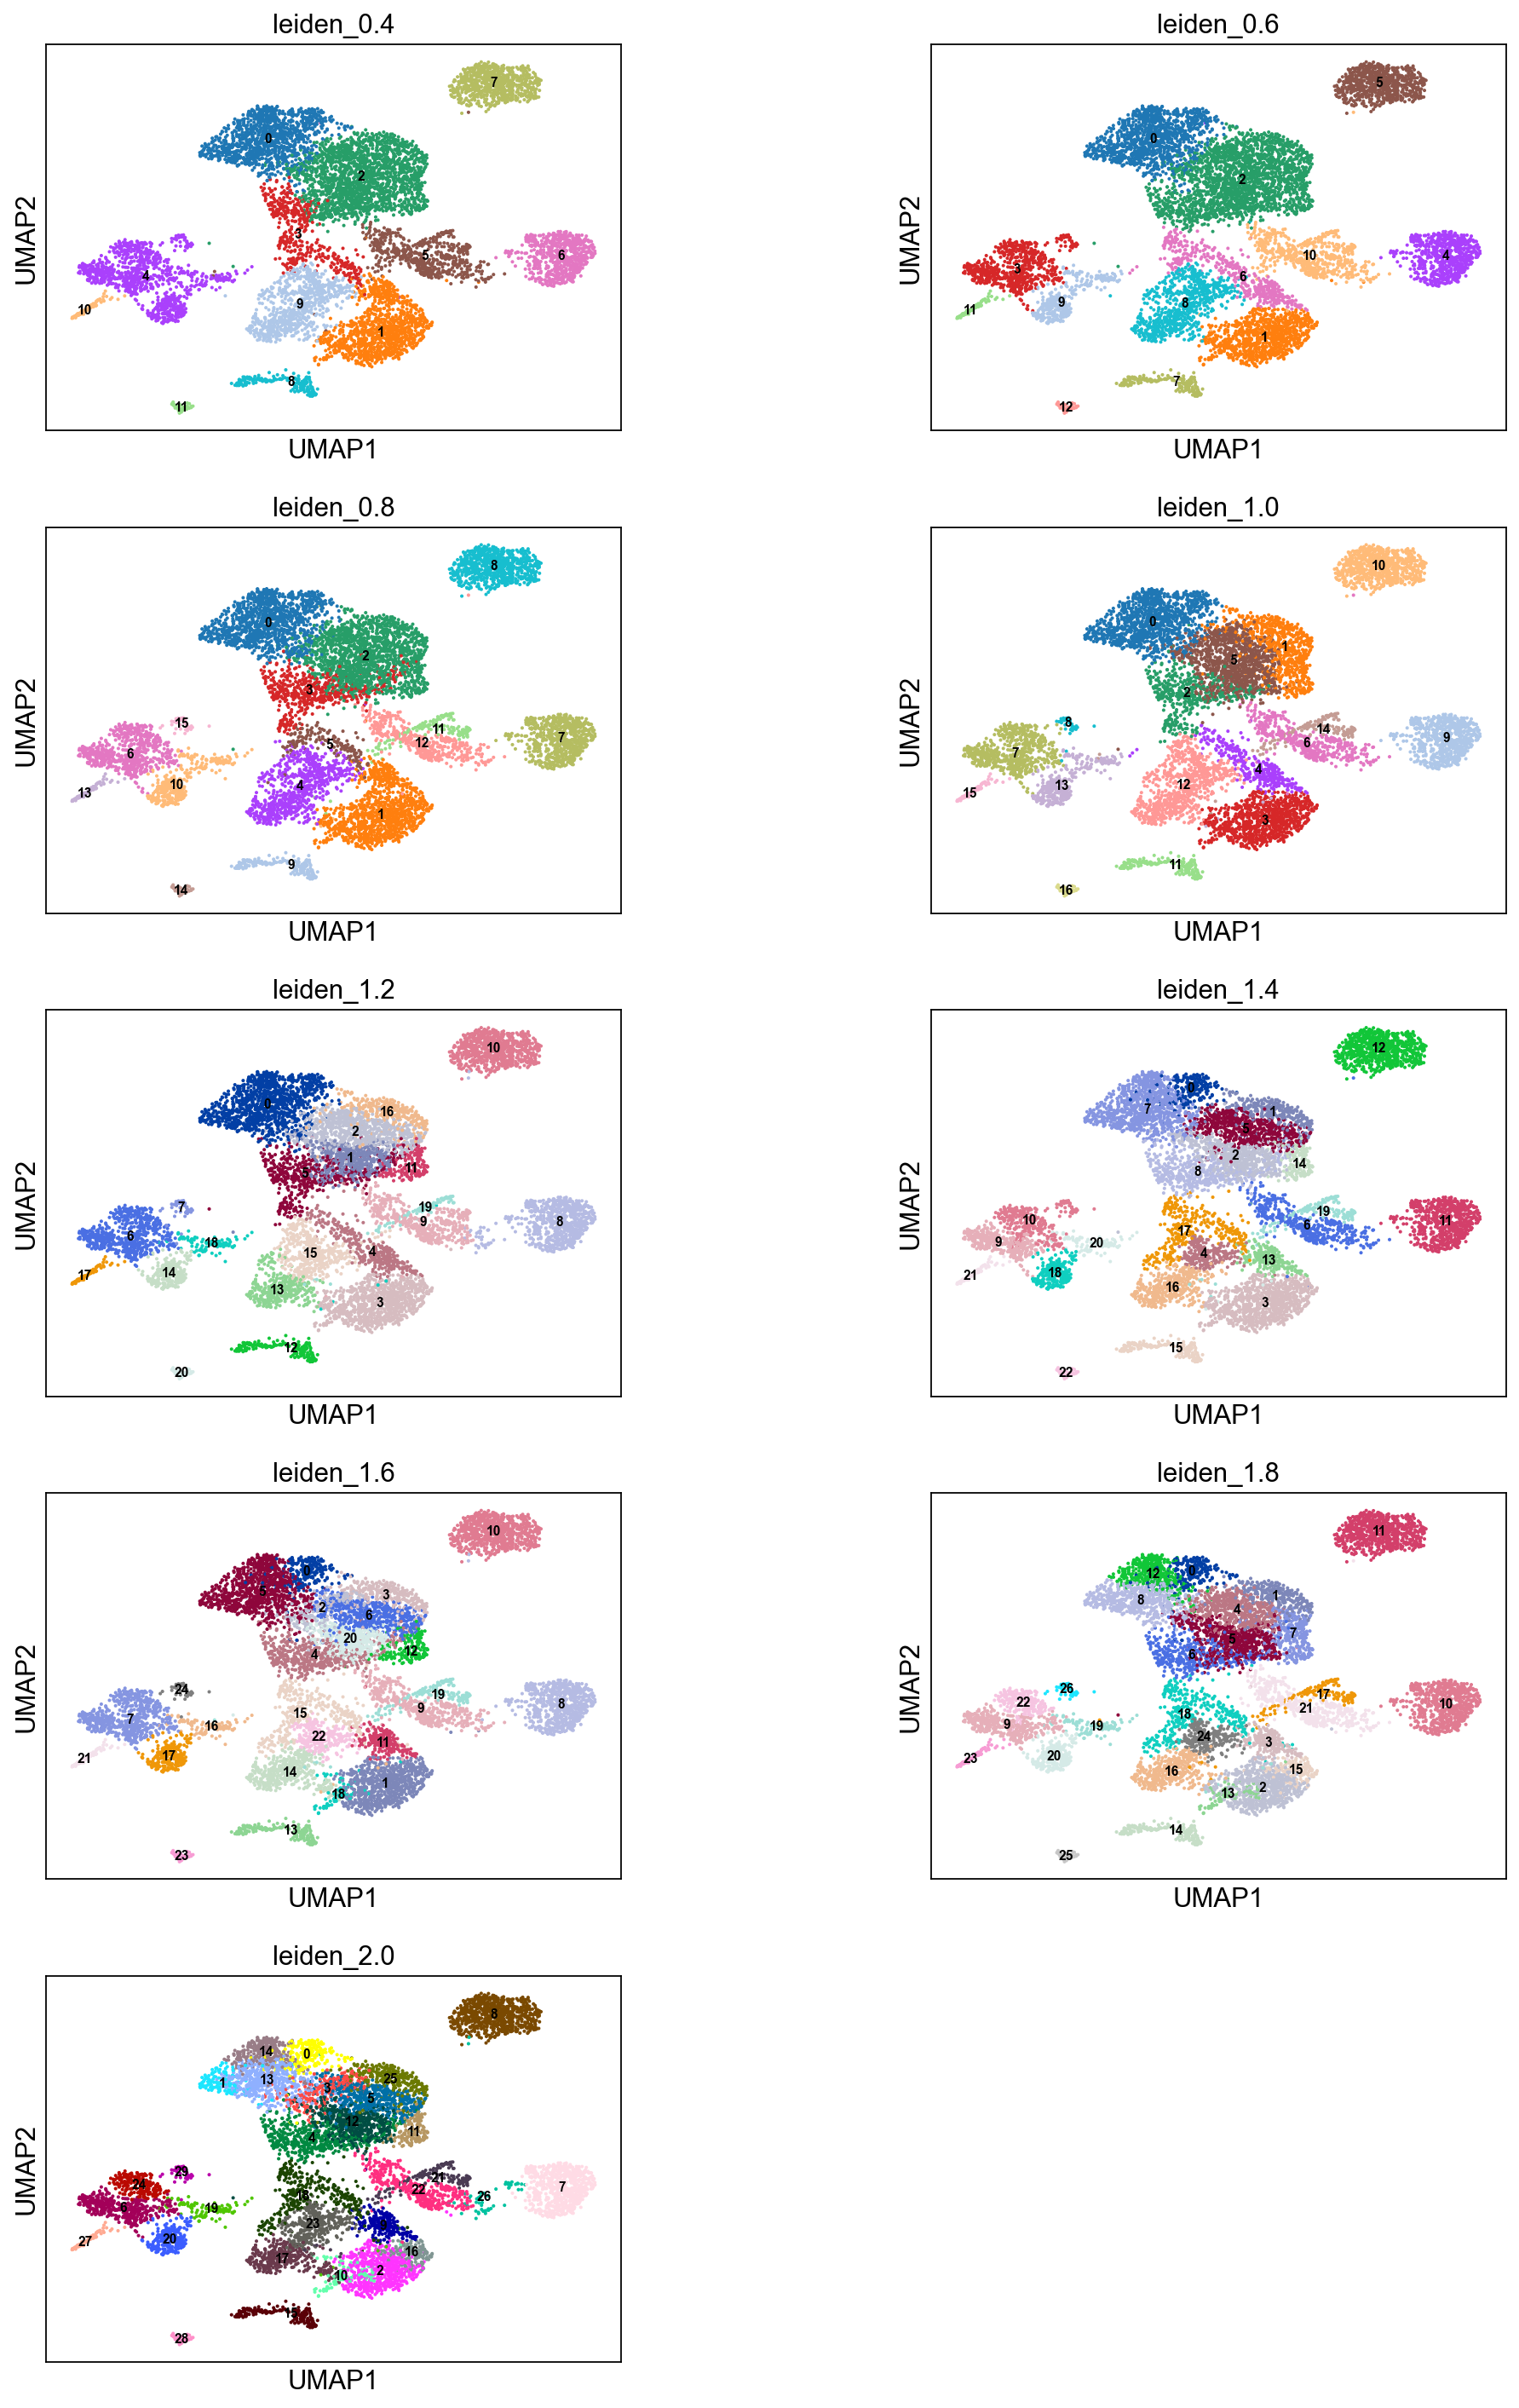

In [ ]:
# UMAP colored by each resolution
sc.pl.umap(
    adata,
    color=[f"leiden_{r}" for r in RESOLUTIONS],
    ncols=2,
    legend_loc="on data",
    legend_fontsize=7,
    wspace=0.4,
)

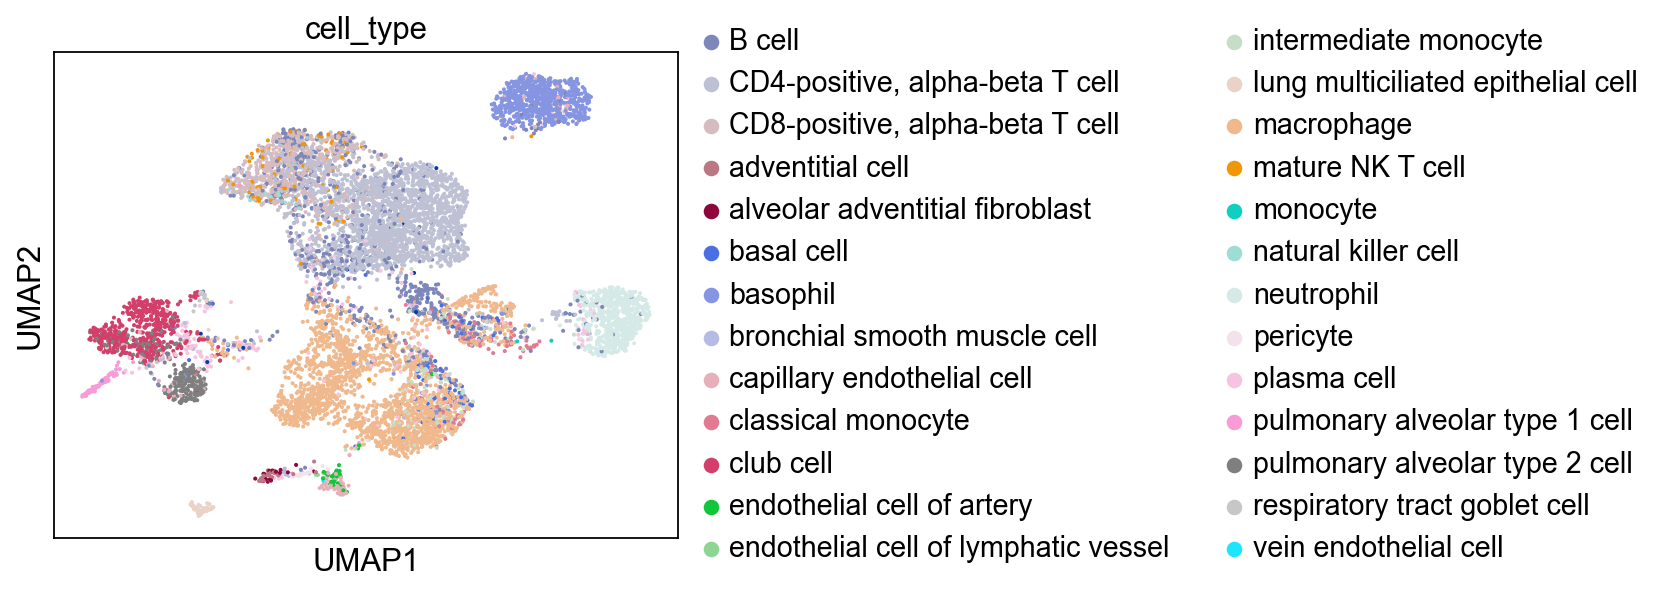

In [ ]:
# STATE annotations for reference
sc.pl.umap(adata, color="cell_type")# legend_loc="on data", legend_fontsize=7)

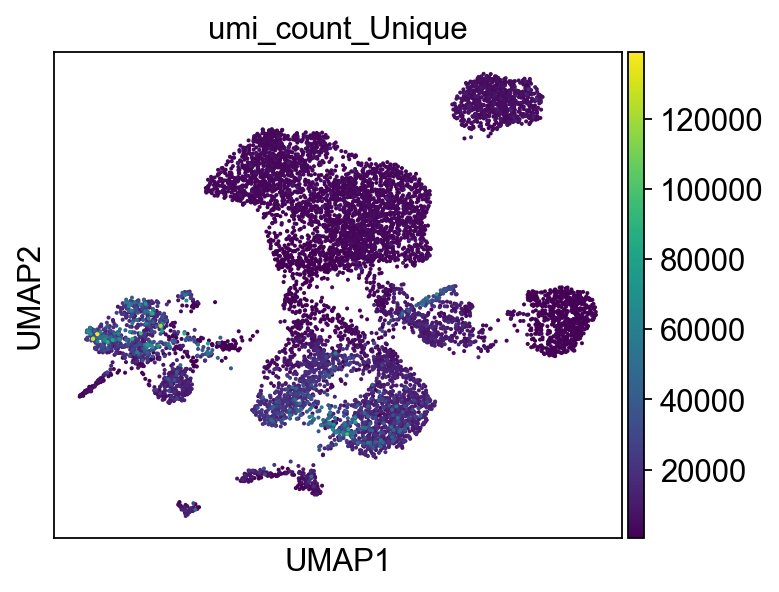

,gene_count_Unique,umi_count_Unique,gene_count_UniqueAndMult-EM,umi_count_UniqueAndMult-EM,gene_count_UniqueAndMult-Uniform,umi_count_UniqueAndMult-Uniform,SRX_accession,cell_type,cell_ontology_term_id,n_genes_by_counts,...,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes,leiden_0.4,leiden_0.6,leiden_0.8,leiden_1.0
AAACCCAAGAAGTCTA,1717,3863.0,1820,3977.000244,1840,3976.999512,SRX13198730,B cell,CL:0000236,1717,...,68.107688,72.0,1.863836,482.0,12.477349,1717,0,0,0,0
AAACCCAAGGCGCTTC,3014,10373.0,3157,10696.999023,3204,10696.999023,SRX13198730,macrophage,CL:0000235,3014,...,64.879977,286.0,2.757158,1090.0,10.508050,3014,1,1,1,3
AAACCCAAGTAGAGTT,981,2201.0,1028,2283.000000,1041,2283.000000,SRX13198730,"CD4-positive, alpha-beta T cell",CL:0000624,981,...,78.146297,126.0,5.724671,445.0,20.218082,981,2,2,2,5
AAACCCACAGATTAAG,1276,2315.0,1350,2395.000000,1369,2395.000000,SRX13198730,mature NK T cell,CL:0000814,1276,...,66.479482,94.0,4.060475,375.0,16.198704,1276,0,0,0,0
AAACCCACAGGTCAAG,991,1638.0,1027,1716.000122,1041,1716.000122,SRX13198730,"CD4-positive, alpha-beta T cell",CL:0000624,991,...,70.024420,74.0,4.517704,217.0,13.247864,991,3,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGCATCGCTCT,418,700.0,459,726.000000,460,726.000000,SRX13198730,neutrophil,CL:0000775,418,...,100.000000,7.0,1.000000,13.0,1.857143,418,6,4,7,9
TTTGTTGGTACGATCT,2492,8236.0,2613,8476.000977,2658,8475.999023,SRX13198730,basophil,CL:0000767,2492,...,66.864983,62.0,0.752793,1031.0,12.518212,2492,7,5,8,10
TTTGTTGGTCCAAAGG,698,1386.0,730,1429.000000,746,1429.000000,SRX13198730,neutrophil,CL:0000775,698,...,85.714286,24.0,1.731602,26.0,1.875902,698,6,4,7,9
TTTGTTGGTGAATGTA,466,648.0,506,693.999939,511,693.999939,SRX13198730,B cell,CL:0000236,466,...,100.000000,22.0,3.395061,95.0,14.660494,466,3,2,3,2


In [ ]:
# STATE annotations for reference
sc.pl.umap(
    adata,
    color="umi_count_Unique",
    # color="gene_count_Unique",
    # legend_loc="on data",
    # legend_fontsize=7
)
adata.obs

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from numpy.typing import NDArray
from typing import Any
from tqdm import tqdm

def _run_classification(
    X: NDArray[np.float32],
    cluster_ids_arr: NDArray[np.str_],
) -> dict[str, dict[str, Any]]:
    """Train LR with stratified CV using cluster IDs as class labels."""
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import LabelEncoder
 
    le = LabelEncoder()
    le.fit(cluster_ids_arr)
    y: NDArray[np.intp] = np.asarray(le.transform(cluster_ids_arr), dtype=np.intp)
    n_classes = int(np.unique(y).shape[0])
    n_cells = int(X.shape[0])
 
    label_counts: NDArray[np.intp] = np.bincount(np.asarray(y, dtype=np.intp))
    min_class_size = int(label_counts.min())
 
    # if min_class_size < 2:
    #     logger.warning("Cell classifier: smallest class has <2 cells, skipping")
    #     return {}
 
    # Keep CV bounded for predictable runtime on large jobs.
    n_splits = min(3, min_class_size)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    held_out_probas: NDArray[np.float64] = np.zeros((n_cells, n_classes))
 
    for train_idx, test_idx in tqdm(skf.split(X, y), desc="Training LR"):
        train_idx_arr: NDArray[np.intp] = np.asarray(train_idx)
        test_idx_arr: NDArray[np.intp] = np.asarray(test_idx)
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                solver="saga",
                C=1.0,
                max_iter=300,
                tol=1e-2,
                random_state=42,
            ),
        )
        clf.fit(X[train_idx_arr], y[train_idx_arr])
        held_out_probas[test_idx_arr] = clf.predict_proba(X[test_idx_arr])
 
    results: dict[str, dict[str, Any]] = {}
 
    for cid in tqdm(np.unique(cluster_ids_arr), desc="Evaluating clusters"):
        mask: NDArray[np.bool_] = cluster_ids_arr == cid
        cluster_y: NDArray[np.intp] = y[mask]
        cluster_probas: NDArray[np.float64] = held_out_probas[mask]
        cluster_preds: NDArray[np.intp] = np.argmax(cluster_probas, axis=1)
 
        accuracy = float(np.asarray(cluster_y == cluster_preds).mean())
 
        safe_probas: NDArray[np.float64] = np.clip(cluster_probas, 1e-10, 1.0)
        per_cell_entropy = np.sum(safe_probas * np.log(safe_probas), axis=1)
        entropy = -float(np.asarray(per_cell_entropy).mean())
 
        pred_labels: NDArray[Any] = np.asarray(le.inverse_transform(cluster_preds))
        unique_preds, counts = np.unique(pred_labels, return_counts=True)
        n_cluster_cells = int(mask.sum())
        profile = {
            str(lbl): round(float(cnt / n_cluster_cells), 4)
            for lbl, cnt in zip(unique_preds, counts)
        }
 
        results[str(cid)] = {
            "classificationAccuracy": round(accuracy, 4),
            "meanEntropy": round(entropy, 4),
            "subPopulationProfile": profile,
            "nCells": n_cluster_cells,
        }
 
    msg = (
        f"Cell classifier: {n_cells} cells, {len(results)} clusters, "
        + f"{n_classes} classes, {n_splits}-fold CV"
    )
    # logger.info(msg)
    return results
 

In [ ]:
res = _run_classification(adata.X[:, adata.var.highly_variable.values].toarray(), adata.obs['leiden_1.0'].values)

Training LR: 3it [00:39, 13.06s/it]
Evaluating clusters: 100%|██████████| 17/17 [00:00<00:00, 4118.24it/s]


In [ ]:
for i in res:
    if res[i]['classificationAccuracy'] < 0.6:
        print (i)
        print (pd.Series(res[i]['subPopulationProfile'], name=i).sort_values(ascending=False))

2
2     0.5680
5     0.2181
1     0.0648
0     0.0626
7     0.0194
12    0.0173
4     0.0151
6     0.0130
3     0.0108
13    0.0043
16    0.0043
10    0.0022
Name: 2, dtype: float64
